Generation 50: Best Fitness = 9273
Generation 100: Best Fitness = 9273
Best Path Found: [21, 19, 18, 4, 29, 22, 8, 10, 6, 5, 16, 17, 25, 24, 20, 15, 14, 23, 1, 9, 28, 12, 13, 26, 7, 2, 27, 11, 30, 3]
Total Cost: 9273


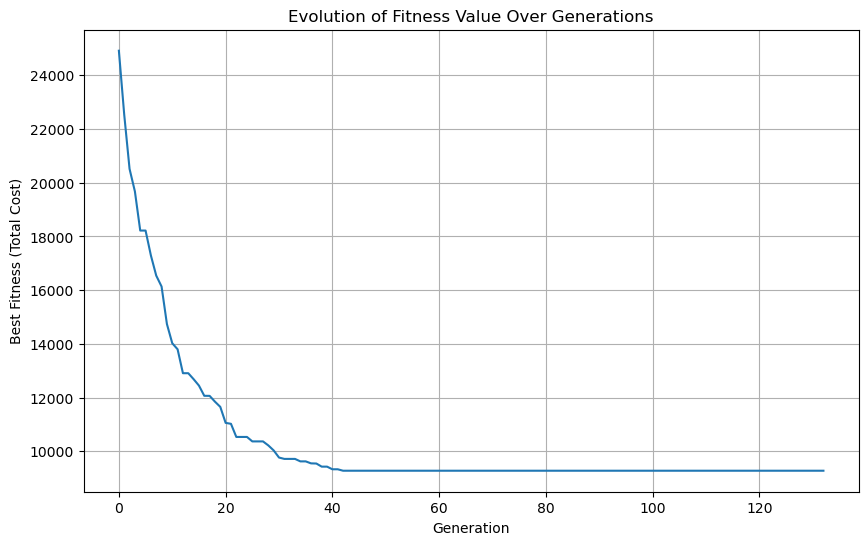

In [1]:
import random
import matplotlib.pyplot as plt


def initialize_population(mu, n):
    population = []
    for _ in range(mu):
        individual = list(range(1, n+1))
        random.shuffle(individual)
        population.append(individual)
    return population

def fitness(individual, matrix):
    total = 0
    n = len(individual)
    for i in range(n):
        current = individual[i] - 1  # convert to 0-based index
        next_ = individual[(i + 1) % n] - 1
        total += matrix[current][next_]
    return total

def tournament_selection(population, tournament_size, matrix):
    participants = random.sample(population, tournament_size)
    participants.sort(key=lambda x: fitness(x, matrix))
    return participants[0]

def order_crossover(parent1, parent2):
    size = len(parent1)
    child = [-1] * size
    start = random.randint(0, size - 1)
    end = random.randint(start, size - 1)
    # Copy segment from parent1
    for i in range(start, end + 1):
        child[i] = parent1[i]
    # Collect elements from parent2 not in the segment
    segment_elements = set(child[start:end + 1])
    remaining = [x for x in parent2 if x not in segment_elements]
    # Fill the child
    ptr = 0
    # Fill from end+1 to end, wrapping around
    for i in list(range(end + 1, size)) + list(range(0, end + 1)):
        if child[i] == -1 and ptr < len(remaining):
            child[i] = remaining[ptr]
            ptr += 1
    return child

def inversion_mutation(individual):
    individual = individual.copy()
    start = random.randint(0, len(individual) - 1)
    end = random.randint(start, len(individual) - 1)
    individual[start:end+1] = individual[start:end+1][::-1]
    return individual

def genetic_algorithm(matrix, n, mu=100, lambda_=100, generations=500, cx_prob=0.8, mt_prob=0.2, stagnation_limit=100):
    population = initialize_population(mu, n)
    best_fitness = float('inf')
    best_individual = None
    fitness_history = []
    stagnation = 0
    
    for gen in range(1, generations+1):
        # Generate offspring
        offspring = []
        for _ in range(lambda_):
            parent1 = tournament_selection(population, 3, matrix)
            parent2 = tournament_selection(population, 3, matrix)
            if random.random() < cx_prob:
                child = order_crossover(parent1, parent2)
            else:
                child = random.choice([parent1, parent2]).copy()
            if random.random() < mt_prob:
                child = inversion_mutation(child)
            offspring.append(child)
        # Combine parents and offspring
        combined = population + offspring
        # Select survivors
        combined.sort(key=lambda x: fitness(x, matrix))
        population = combined[:mu]
        # Update best solution
        current_best_fitness = fitness(population[0], matrix)
        if current_best_fitness < best_fitness:
            best_fitness = current_best_fitness
            best_individual = population[0].copy()
        else:
            stagnation += 1

        fitness_history.append(best_fitness)
        if gen % 50==0:
            print(f"Generation {gen}: Best Fitness = {best_fitness}")

        if stagnation >= stagnation_limit:
            break
    
    return best_individual, best_fitness, fitness_history

# Read input data
# Using the provided example data

# txt = """4  
# 99999        
# 99999 5 10 3  
# 5 99999 7 8   
# 10 7 99999 12 
# 3 8 12 99999"""

with open("data.txt", 'r') as file:
    lines = file.readlines()
    file.close()
# lines = txt.split('\n')
for i in range(len(lines)):
    lines[i] = list(map(int, lines[i].split()))
n, no_path, matrix = lines[0][0], lines[1][0], lines[2:]

# Run the genetic algorithm
best_path, best_cost, fitness_history = genetic_algorithm(matrix, n, mu=500, lambda_=1000, generations=500, cx_prob=0.8, mt_prob=0.2, stagnation_limit=101)

# Output the results
print("Best Path Found:", best_path)
print("Total Cost:", best_cost)

# Plot fitness evolution
plt.figure(figsize=(10, 6))
plt.plot(fitness_history)
plt.title('Evolution of Fitness Value Over Generations')
plt.xlabel('Generation')
plt.ylabel('Best Fitness (Total Cost)')
plt.grid(True)
plt.show()